# Practical Application III: Comparing Classifiers

**Overview**: In this practical application, your goal is to compare the performance of the classifiers we encountered in this section, namely K Nearest Neighbor, Logistic Regression, Decision Trees, and Support Vector Machines.  We will utilize a dataset related to marketing bank products over the telephone.  



### Getting Started

Our dataset comes from the UCI Machine Learning repository [link](https://archive.ics.uci.edu/ml/datasets/bank+marketing).  The data is from a Portugese banking institution and is a collection of the results of multiple marketing campaigns.  We will make use of the article accompanying the dataset [here](CRISP-DM-BANK.pdf) for more information on the data and features.



### Problem 1: Understanding the Data

To gain a better understanding of the data, please read the information provided in the UCI link above, and examine the **Materials and Methods** section of the paper.  How many marketing campaigns does this data represent?

### Problem 2: Read in the Data

Use pandas to read in the dataset `bank-additional-full.csv` and assign to a meaningful variable name.

In [64]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder,LabelEncoder
from sklearn.compose import make_column_transformer
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.feature_selection import SelectFromModel
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier,export_text, plot_tree
from sklearn.ensemble import VotingClassifier
from itertools import product
from sklearn.decomposition import PCA, KernelPCA
from sklearn.metrics.pairwise import polynomial_kernel, rbf_kernel
from sklearn.svm import SVC
from sklearn.compose import ColumnTransformer
from sklearn.metrics import classification_report


from sklearn.metrics import roc_curve, auc, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay,mean_squared_error,accuracy_score,PrecisionRecallDisplay,precision_score,recall_score,f1_score,precision_recall_curve
from sklearn.inspection import DecisionBoundaryDisplay
import time



import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [72]:

#df = pd.read_csv('data/bank-additional/bank-additional-full.csv', sep = ';')
df =pd.read_csv('data/bank-additional-full.csv', sep = ';')


In [74]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


### Problem 3: Understanding the Features


Examine the data description below, and determine if any of the features are missing values or need to be coerced to a different data type.


```
Input variables:
# bank client data:
1 - age (numeric)
2 - job : type of job (categorical: 'admin.','blue-collar','entrepreneur','housemaid','management','retired','self-employed','services','student','technician','unemployed','unknown')
3 - marital : marital status (categorical: 'divorced','married','single','unknown'; note: 'divorced' means divorced or widowed)
4 - education (categorical: 'basic.4y','basic.6y','basic.9y','high.school','illiterate','professional.course','university.degree','unknown')
5 - default: has credit in default? (categorical: 'no','yes','unknown')
6 - housing: has housing loan? (categorical: 'no','yes','unknown')
7 - loan: has personal loan? (categorical: 'no','yes','unknown')
# related with the last contact of the current campaign:
8 - contact: contact communication type (categorical: 'cellular','telephone')
9 - month: last contact month of year (categorical: 'jan', 'feb', 'mar', ..., 'nov', 'dec')
10 - day_of_week: last contact day of the week (categorical: 'mon','tue','wed','thu','fri')
11 - duration: last contact duration, in seconds (numeric). Important note: this attribute highly affects the output target (e.g., if duration=0 then y='no'). Yet, the duration is not known before a call is performed. Also, after the end of the call y is obviously known. Thus, this input should only be included for benchmark purposes and should be discarded if the intention is to have a realistic predictive model.
# other attributes:
12 - campaign: number of contacts performed during this campaign and for this client (numeric, includes last contact)
13 - pdays: number of days that passed by after the client was last contacted from a previous campaign (numeric; 999 means client was not previously contacted)
14 - previous: number of contacts performed before this campaign and for this client (numeric)
15 - poutcome: outcome of the previous marketing campaign (categorical: 'failure','nonexistent','success')
# social and economic context attributes
16 - emp.var.rate: employment variation rate - quarterly indicator (numeric)
17 - cons.price.idx: consumer price index - monthly indicator (numeric)
18 - cons.conf.idx: consumer confidence index - monthly indicator (numeric)
19 - euribor3m: euribor 3 month rate - daily indicator (numeric)
20 - nr.employed: number of employees - quarterly indicator (numeric)

Output variable (desired target):
21 - y - has the client subscribed a term deposit? (binary: 'yes','no')
```



In [76]:
# Check if there are any null values in the dataset
if df.isnull().values.any():
    print("There are null values in the dataset.")
else:
    print("No null values found in the dataset.")

No null values found in the dataset.


Axes(0.125,0.11;0.775x0.77)
Axes(0.125,0.11;0.775x0.77)


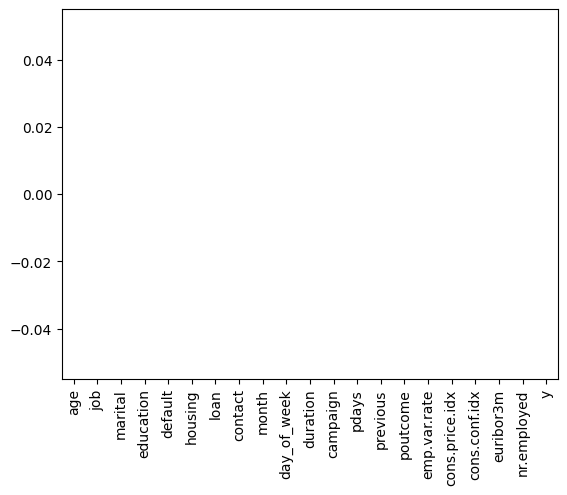

In [7]:
#Plotting null values in each feature
print(df.isnull().sum().plot.bar())
print(df.isna().sum().plot.bar())


### Problem 4: Understanding the Task

After examining the description and data, your goal now is to clearly state the *Business Objective* of the task.  State the objective below.

The objective of this project is to compare different classifiers (k-nearest neighbors, logistic regression, decision trees, and support vector machines) using the bank marketing dataset from the UCI Machine Learning Repository. The goal is to determine the most accurate and reliable model for predicting the success of a marketing campaign for a bank.


In [78]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

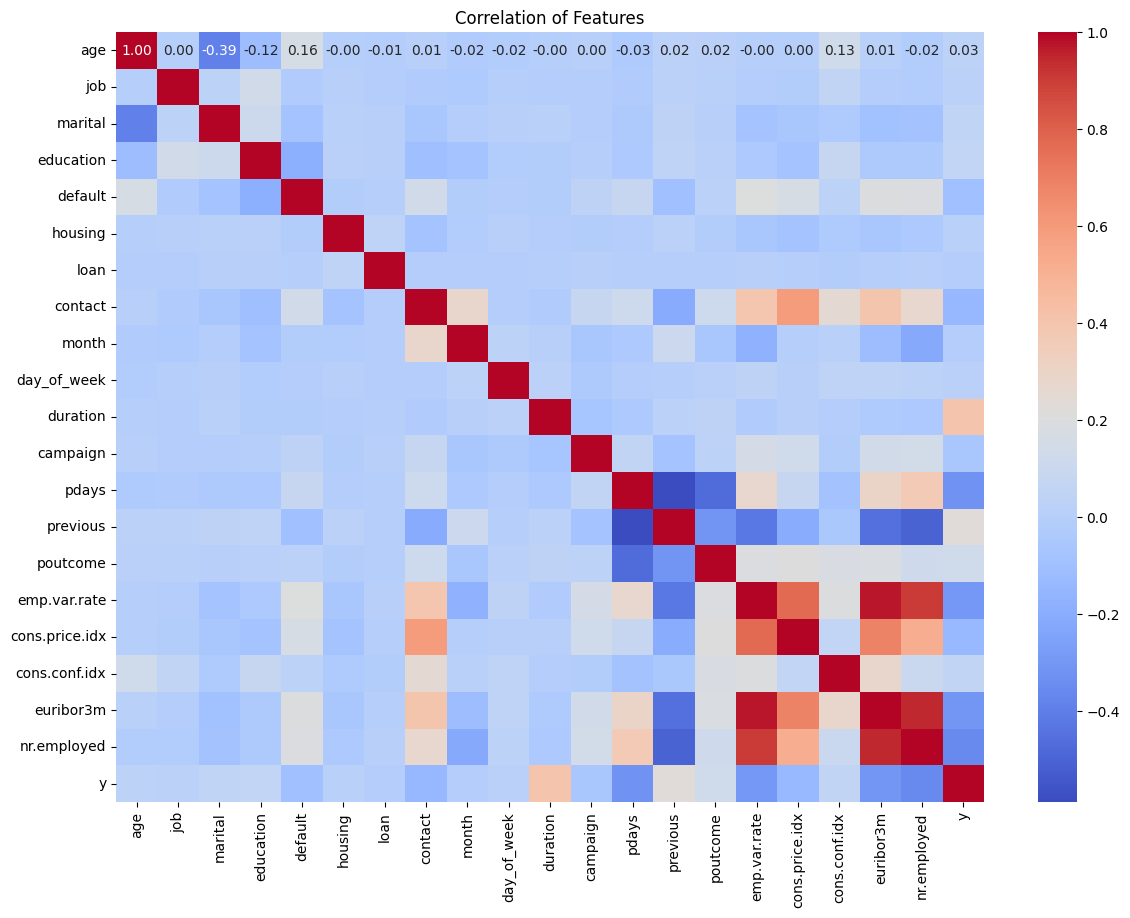

In [116]:
# Visualize the correlation matrix
plt.figure(figsize=(14,10))
sns.heatmap(df_corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation of Features')
plt.show()

### Problem 5: Engineering Features

Now that you understand your business objective, we will build a basic model to get started.  Before we can do this, we must work to encode the data.  Using just the bank information features, prepare the features and target column for modeling with appropriate encoding and transformations.

In [80]:
# Convert categorical columns to numeric using LabelEncoder for simplicity
label_encoder = LabelEncoder()
df_encoded = df.copy()

# Encoding all categorical columns
categorical_columns = df.select_dtypes(include=['object']).columns
for col in categorical_columns:
    df_encoded[col] = label_encoder.fit_transform(df[col])

# Separating the features and the target variable
X = df_encoded.drop(columns=['y'])
y = df_encoded['y']



y
no     36548
yes     4640
Name: count, dtype: int64

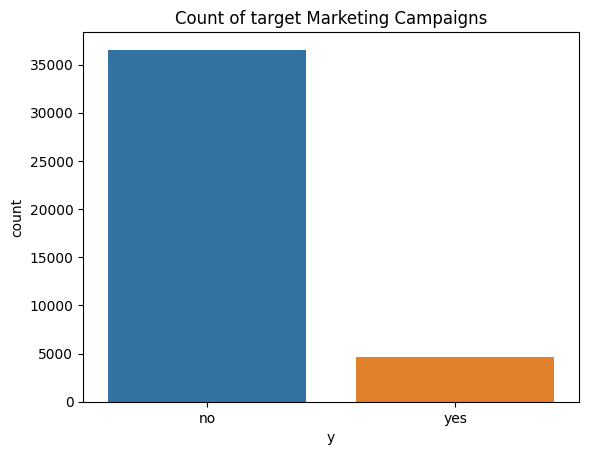

In [82]:
df_encoded['y'] = np.where(df['y']== 'yes', 'Successful', 'Failure')

sns.countplot(data=df, x = 'y')
plt.title('Count of target Marketing Campaigns')
df['y'].value_counts()

### Problem 6: Train/Test Split

With your data prepared, split it into a train and test set.

In [11]:

# Split the dataset into training and testing sets (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Displaying the shapes of the train and test sets
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((32950, 20), (8238, 20), (32950,), (8238,))

### Problem 7: A Baseline Model

Before we build our first model, we want to establish a baseline.  What is the baseline performance that our classifier should aim to beat?

In [12]:
#To establish a baseline performance, we can look at the most frequent class in the target variable (y) and assume a "dummy" classifier
#that always predicts this most frequent class. This provides a baseline accuracy that any model should aim to beat.
# Calculate the baseline accuracy by finding the most frequent class in the target variable
baseline_class = y_train.mode()[0]
baseline_accuracy = (y_train == baseline_class).mean()

baseline_accuracy

0.887556904400607

In [84]:
from sklearn.dummy import DummyClassifier

# Dictionary to store the results of each model
results = []
# Record start time
start_time = time.time()
baseline_model = DummyClassifier(strategy="most_frequent")
baseline_model.fit(X_train, y_train)
# Record end time for training
train_time_baseline = time.time() - start_time

# Make predictions
y_pred = baseline_model.predict(X_test)

# Evaluate performance

train_accuracy_baseline = accuracy_score(y_train, baseline_model.predict(X_train))
test_accuracy_baseline = accuracy


# Append Decision Tree results
results.append({
    "Model": "Baseline",
    "Train Time (s)": train_time_baseline,
    "Train Accuracy": train_accuracy_baseline,
    "Test Accuracy": test_accuracy_baseline
})

results

[{'Model': 'Baseline',
  'Train Time (s)': 0.0033440589904785156,
  'Train Accuracy': 0.887556904400607,
  'Test Accuracy': 0.910536537994659}]

### Problem 8: A Simple Model

Use Logistic Regression to build a basic model on your data.  

In [86]:
from sklearn.linear_model import LogisticRegression

# Create a basic Logistic Regression Model

start_time = time.time()


lr_model = LogisticRegression()
lr_model.fit(X_train, y_train)
# Record end time for training
train_time_lr = time.time() - start_time

# Make the Prediction using the basic Logistic Regression Model on the X_test data
lr_pred = lr_model.predict(X_test)


/Users/zozo/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


### Problem 9: Score the Model

What is the accuracy of your model?

In [88]:
# Evaluate the performance of the model

accuracy  = accuracy_score(y_test, lr_model.predict(X_test))
train_accuracy_lr = accuracy_score(y_train, lr_model.predict(X_train))
test_accuracy_lr = accuracy

# Append Decision Tree results
results.append({
    "Model": "Logistic Regression Basic",
    "Train Time (s)": train_time_lr,
    "Train Accuracy": train_accuracy_lr,
    "Test Accuracy": test_accuracy_lr
})

results

[{'Model': 'Baseline',
  'Train Time (s)': 0.0033440589904785156,
  'Train Accuracy': 0.887556904400607,
  'Test Accuracy': 0.910536537994659},
 {'Model': 'Logistic Regression Basic',
  'Train Time (s)': 0.2807190418243408,
  'Train Accuracy': 0.9079210925644916,
  'Test Accuracy': 0.910536537994659}]

### Problem 10: Model Comparisons

Now, we aim to compare the performance of the Logistic Regression model to our KNN algorithm, Decision Tree, and SVM models.  Using the default settings for each of the models, fit and score each.  Also, be sure to compare the fit time of each of the models.  Present your findings in a `DataFrame` similar to that below:

| Model | Train Time | Train Accuracy | Test Accuracy |
| ----- | ---------- | -------------  | -----------   |
|     |    |.     |.     |

In [90]:


# Dictionary to store the results of each model
#results = []

# 1. Logistic Regression
# Initialize and train the Logistic Regression model
log_reg = LogisticRegression(max_iter=1000)

start_time = time.time()
log_reg.fit(X_train, y_train)
train_time_log_reg = time.time() - start_time

train_accuracy_log_reg = accuracy_score(y_train, log_reg.predict(X_train))
test_accuracy_log_reg = accuracy_score(y_test, log_reg.predict(X_test))

# Append Logistic Regression results
results.append({
    "Model": "Logistic Regression",
    "Train Time (s)": train_time_log_reg,
    "Train Accuracy": train_accuracy_log_reg,
    "Test Accuracy": test_accuracy_log_reg
})


print (results)

[{'Model': 'Baseline', 'Train Time (s)': 0.0033440589904785156, 'Train Accuracy': 0.887556904400607, 'Test Accuracy': 0.910536537994659}, {'Model': 'Logistic Regression Basic', 'Train Time (s)': 0.2807190418243408, 'Train Accuracy': 0.9079210925644916, 'Test Accuracy': 0.910536537994659}, {'Model': 'Logistic Regression', 'Train Time (s)': 2.070539951324463, 'Train Accuracy': 0.9096509863429438, 'Test Accuracy': 0.9109007040543822}]


/Users/zozo/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [92]:
# 2. Decision Tree Classifier
# Initialize and train the Decision Tree model
tree = DecisionTreeClassifier()

start_time = time.time()
tree.fit(X_train, y_train)
train_time_tree = time.time() - start_time

train_accuracy_tree = accuracy_score(y_train, tree.predict(X_train))
test_accuracy_tree = accuracy_score(y_test, tree.predict(X_test))

# Append Decision Tree results
results.append({

    "Model": "Decision Tree",
    "Train Time (s)": train_time_tree,
    "Train Accuracy": train_accuracy_tree,
    "Test Accuracy": test_accuracy_tree
})

print(results)

[{'Model': 'Baseline', 'Train Time (s)': 0.0033440589904785156, 'Train Accuracy': 0.887556904400607, 'Test Accuracy': 0.910536537994659}, {'Model': 'Logistic Regression Basic', 'Train Time (s)': 0.2807190418243408, 'Train Accuracy': 0.9079210925644916, 'Test Accuracy': 0.910536537994659}, {'Model': 'Logistic Regression', 'Train Time (s)': 2.070539951324463, 'Train Accuracy': 0.9096509863429438, 'Test Accuracy': 0.9109007040543822}, {'Model': 'Decision Tree', 'Train Time (s)': 0.14906597137451172, 'Train Accuracy': 1.0, 'Test Accuracy': 0.8895362952172857}]


In [94]:
#3.KNN
import time

# Initialize the K-Nearest Neighbors classifier
knn = KNeighborsClassifier()



# Record start time
start_time = time.time()

# Train the KNN model again
knn.fit(X_train, y_train)



# Record end time for training
train_time_knn = time.time() - start_time
# Train accuracy
train_accuracy_knn = accuracy_score(y_train, knn.predict(X_train))

# Make predictions on the test set
y_pred_knn = knn.predict(X_test)
knn_accuracy = accuracy_score(y_test, y_pred_knn)

# Test accuracy (already calculated)
test_accuracy_knn = knn_accuracy



# Append Decision Tree results
results.append({
    "Model": "K-Nearest Neighbors",
    "Train Time (s)": train_time_knn,
    "Train Accuracy": train_accuracy_knn,
    "Test Accuracy": test_accuracy_knn
})

print(results)


[{'Model': 'Baseline', 'Train Time (s)': 0.0033440589904785156, 'Train Accuracy': 0.887556904400607, 'Test Accuracy': 0.910536537994659}, {'Model': 'Logistic Regression Basic', 'Train Time (s)': 0.2807190418243408, 'Train Accuracy': 0.9079210925644916, 'Test Accuracy': 0.910536537994659}, {'Model': 'Logistic Regression', 'Train Time (s)': 2.070539951324463, 'Train Accuracy': 0.9096509863429438, 'Test Accuracy': 0.9109007040543822}, {'Model': 'Decision Tree', 'Train Time (s)': 0.14906597137451172, 'Train Accuracy': 1.0, 'Test Accuracy': 0.8895362952172857}, {'Model': 'K-Nearest Neighbors', 'Train Time (s)': 0.013569116592407227, 'Train Accuracy': 0.9314719271623673, 'Test Accuracy': 0.902282107307599}]


In [96]:
# 4. Support Vector Machine
# Initialize and train the SVM model
svm = SVC()

start_time = time.time()
svm.fit(X_train, y_train)
train_time_svm = time.time() - start_time

train_accuracy_svm = accuracy_score(y_train, svm.predict(X_train))
test_accuracy_svm = accuracy_score(y_test, svm.predict(X_test))

# Append SVM results
results.append({
    "Model": "Support Vector Machine",
    "Train Time (s)": train_time_svm,
    "Train Accuracy": train_accuracy_svm,
    "Test Accuracy": test_accuracy_svm
})

# Convert results to a DataFrame for display
model_comparison_df = pd.DataFrame(results)

model_comparison_df

,Model,Train Time (s),Train Accuracy,Test Accuracy
0,Baseline,0.003344,0.887557,0.910537
1,Logistic Regression Basic,0.280719,0.907921,0.910537
2,Logistic Regression,2.070540,0.909651,0.910901
3,Decision Tree,0.149066,1.000000,0.889536
4,K-Nearest Neighbors,0.013569,0.931472,0.902282
5,Support Vector Machine,5.227392,0.898483,0.894513


### Problem 11: Improving the Model

Now that we have some basic models on the board, we want to try to improve these.  Below, we list a few things to explore in this pursuit.

- More feature engineering and exploration.  For example, should we keep the gender feature?  Why or why not?
- Hyperparameter tuning and grid search.  All of our models have additional hyperparameters to tune and explore.  For example the number of neighbors in KNN or the maximum depth of a Decision Tree.  
- Adjust your performance metric

In [98]:
#Scaling/Normalization:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

models = {
    'LogisticRegression': LogisticRegression(max_iter=1000, random_state=42),
    'DecisionTree': DecisionTreeClassifier(class_weight='balanced',random_state=42),
    'KNearestNeighbors': KNeighborsClassifier(),
    'SVC': SVC(random_state=42)
}

# Initialize list to store results
model_results = []

# Train and evaluate each model with cross-validation
for model_name, model in models.items():
    # Measure fitting time using cross-validation
    start_time = time.time()
    model.fit(X_train_scaled, y_train)  # Fit the model
    end_time = time.time()
    train_time = end_time - start_time


    # Calculate train and test scores


    train_accuracy = accuracy_score(y_train, model.predict(X_train))
    test_accuracy = accuracy_score(y_test, model.predict(X_test))

    # Store results in the list
    model_results.append({
        'model': model_name,
        'Train Time (s)': train_time,
        'Train Accuracy': train_accuracy,
        'Test Accuracy': test_accuracy
    })
# Convert to DataFrame and display results
results_df = pd.DataFrame(model_results)
results_df.set_index('model', inplace=True)

print( results_df)

/Users/zozo/anaconda3/lib/python3.11/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
/Users/zozo/anaconda3/lib/python3.11/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
/Users/zozo/anaconda3/lib/python3.11/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
/Users/zozo/anaconda3/lib/python3.11/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
/Users/zozo/anaconda3/lib/python3.11/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(
/Users/zozo/anaconda3/lib/python3.11/site-packages/sklearn/base.py:486: UserWarning: X has feat

                    Train Time (s)  Train Accuracy  Test Accuracy
model                                                            
LogisticRegression        0.087882        0.887527       0.886502
DecisionTree              0.147880        0.887466       0.886502
KNearestNeighbors         0.001732        0.120091       0.121753
SVC                       4.785589        0.887557       0.886502


In [100]:
#Get correlations of all features with 'y'

df_encoded = df.copy()

# Encoding all categorical columns
categorical_columns = df.select_dtypes(include=['object']).columns
for col in categorical_columns:
    df_encoded[col] = label_encoder.fit_transform(df[col])

# Separating the features and the target variable
X = df_encoded.drop(columns=['y'])
y = df_encoded['y']


# Split the dataset into training and testing sets (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Displaying the shapes of the train and test sets
X_train.shape, X_test.shape, y_train.shape, y_test.shape


label_encoder = LabelEncoder()
df_encoded['y'] = label_encoder.fit_transform(df['y'])  # 'yes' becomes 1, 'no' becomes 0

# Select numeric columns including 'y'
df_numeric_only = df_encoded.select_dtypes(include=[float, int])

# Recalculate the correlation matrix including 'y'
df_corr = df_numeric_only.corr()

# Get correlations of all features with 'y'
corr_with_target = df_corr['y'].sort_values(ascending=False)
print("Correlation of features with the target variable 'y':")
print(corr_with_target)


Correlation of features with the target variable 'y':
y                 1.000000
duration          0.405274
previous          0.230181
poutcome          0.129789
education         0.057799
cons.conf.idx     0.054878
marital           0.046203
age               0.030399
job               0.025122
day_of_week       0.015967
housing           0.011552
loan             -0.004909
month            -0.006065
campaign         -0.066357
default          -0.099352
cons.price.idx   -0.136211
contact          -0.144773
emp.var.rate     -0.298334
euribor3m        -0.307771
pdays            -0.324914
nr.employed      -0.354678
Name: y, dtype: float64


Strong Positive Correlation (Above 0.2): duration, previous

Strong Negative Correlation (Below -0.2): emp.var.rate, euribor3m, pdays, nr.employed

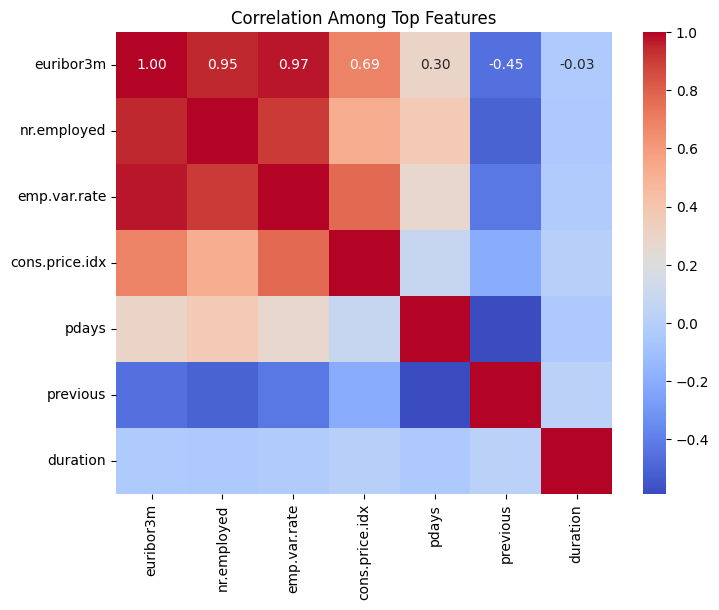

In [102]:
# List of top features based on correlation with 'y'
top_features = ['euribor3m', 'nr.employed', 'emp.var.rate', 'cons.price.idx', 'pdays', 'previous', 'duration']

# Create a correlation matrix for top features
corr_top_features = df_corr.loc[top_features, top_features]

# Visualize the correlation matrix
plt.figure(figsize=(8,6))
sns.heatmap(corr_top_features, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Among Top Features')
plt.show()

High Strong Positive Correlation (Above 0.8)

euribor3m, nr.employed, and emp.var.rate are likely to be highly correlated\
High Negative Correlation (Below -0.5):

pdays and previous might also be highly correlated.
Features to Consider Dropping or Transforming age and campaign: Low correlation with y; assess their importance using feature importance from models.

Features with Near-Zero Variance: Remove features that have little variability across the dataset.

In [104]:
# Based on the correlation analysis, keep these features
features_to_keep = ['euribor3m', 'nr.employed', 'emp.var.rate', 'cons.price.idx', 'duration', 'pdays', 'previous']

# Drop the rest of the columns from the dataframe
df_selected = df_encoded[features_to_keep + ['y']]  # Include 'y' as the target variable

# Display the updated dataframe with selected features
print(df_selected.head())




X_selected = df_selected.drop(columns=['y'])
y_selected = df_selected['y']


X_train, X_test, y_train, y_test = train_test_split(X_selected, y_selected, test_size=0.2, random_state=42)





   euribor3m  nr.employed  emp.var.rate  cons.price.idx  duration  pdays  \
0      4.857       5191.0           1.1          93.994       261    999   
1      4.857       5191.0           1.1          93.994       149    999   
2      4.857       5191.0           1.1          93.994       226    999   
3      4.857       5191.0           1.1          93.994       151    999   
4      4.857       5191.0           1.1          93.994       307    999   

   previous  y  
0         0  0  
1         0  0  
2         0  0  
3         0  0  
4         0  0  


In [106]:
#Logistic Regression - GridSearchCV

from sklearn.model_selection import GridSearchCV


# Dictionary to store results
grid_results = []

# 1. Logistic Regression with GridSearchCV
log_reg_param_grid = {'C': [0.01, 0.1, 1, 10, 100]}
log_reg = LogisticRegression(penalty='l2', max_iter=1000)
log_reg_search = GridSearchCV(log_reg, param_grid=log_reg_param_grid, cv=5)

start_time = time.time()
log_reg_search.fit(X_train, y_train)
train_time_log_reg = time.time() - start_time

train_accuracy_log_reg = log_reg_search.best_score_
test_accuracy_log_reg = accuracy_score(y_test, log_reg_search.predict(X_test))
best_params_log_reg = log_reg_search.best_params_

grid_results.append({
    "Model": "Logistic Regression",
    "Train Time (s)": train_time_log_reg,
    "Train Accuracy": train_accuracy_log_reg,
    "Test Accuracy": test_accuracy_log_reg,
    "Best Params": best_params_log_reg
})

grid_results



[{'Model': 'Logistic Regression',
  'Train Time (s)': 8.610735177993774,
  'Train Accuracy': 0.908710166919575,
  'Test Accuracy': 0.9077445982034474,
  'Best Params': {'C': 1}}]

In [108]:
# 2. Decision Tree with GridSearchCV
tree_param_grid = {'max_depth': [5, 10, 15], 'min_samples_split': [2, 5, 10]}
tree = DecisionTreeClassifier()
tree_search = GridSearchCV(tree, param_grid=tree_param_grid, cv=5)

start_time = time.time()
tree_search.fit(X_train, y_train)
train_time_tree = time.time() - start_time

train_accuracy_tree = tree_search.best_score_
test_accuracy_tree = accuracy_score(y_test, tree_search.predict(X_test))
best_params_tree = tree_search.best_params_

grid_results.append({
    "Model": "Decision Tree",
    "Train Time (s)": train_time_tree,
    "Train Accuracy": train_accuracy_tree,
    "Test Accuracy": test_accuracy_tree,
    "Best Params": best_params_tree
})
grid_results

[{'Model': 'Logistic Regression',
  'Train Time (s)': 8.610735177993774,
  'Train Accuracy': 0.908710166919575,
  'Test Accuracy': 0.9077445982034474,
  'Best Params': {'C': 1}},
 {'Model': 'Decision Tree',
  'Train Time (s)': 1.1795928478240967,
  'Train Accuracy': 0.9130804248861912,
  'Test Accuracy': 0.91442097596504,
  'Best Params': {'max_depth': 5, 'min_samples_split': 2}}]

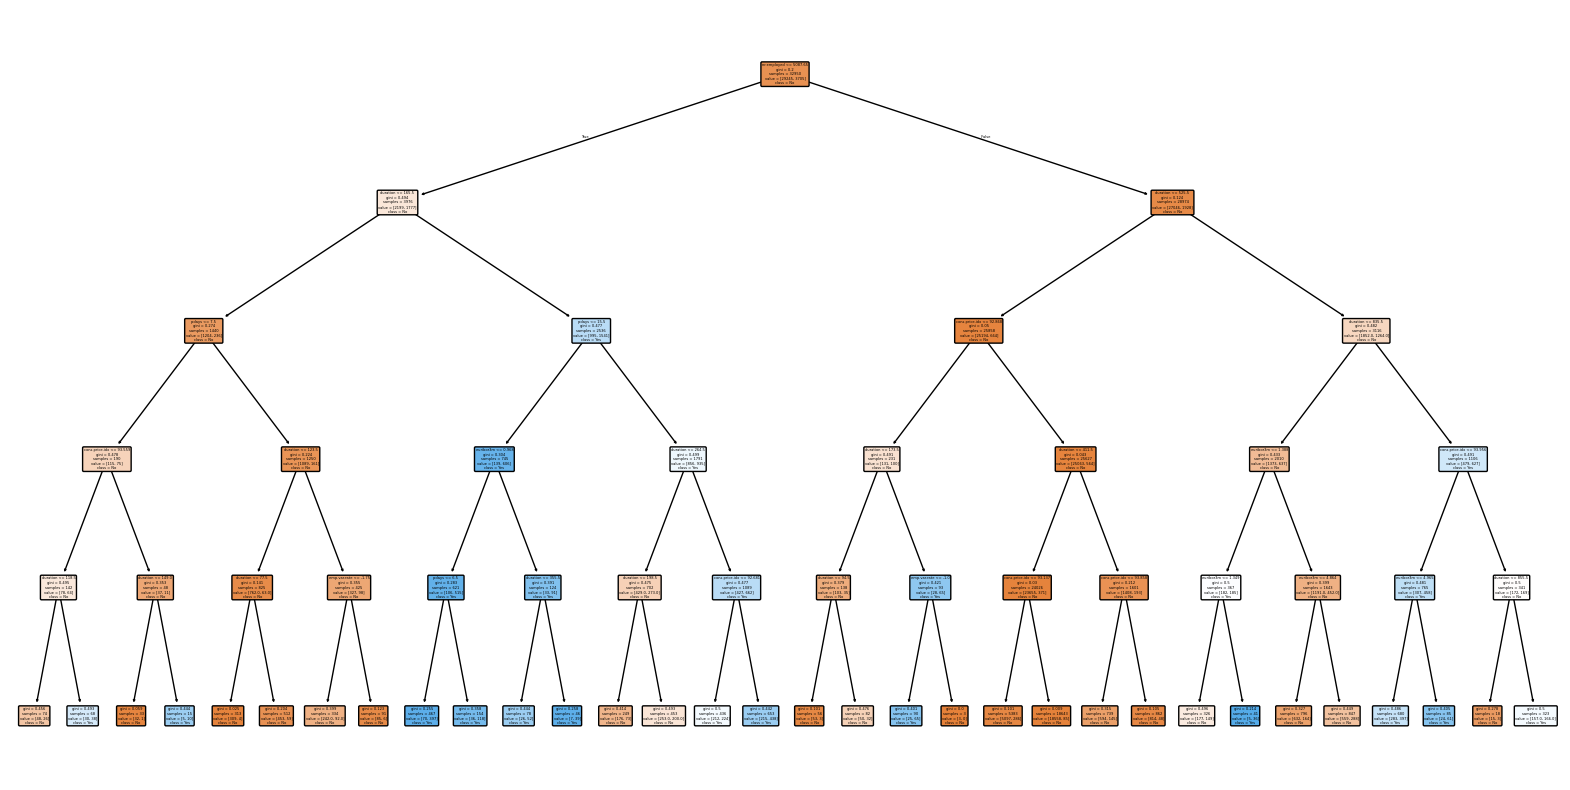

In [110]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# Retrieve the best Decision Tree model from GridSearchCV
best_tree = tree_search.best_estimator_

# Plot the decision tree
plt.figure(figsize=(20,10))  # Adjust size as needed
plot_tree(best_tree, filled=True, feature_names=X_train.columns, class_names=['No', 'Yes'], rounded=True)
plt.show()


In [112]:
# 3. K-Nearest Neighbors with GridSearchCV
knn_param_grid = {'n_neighbors': [3, 5, 7, 9]}
knn = KNeighborsClassifier()
knn_search = GridSearchCV(knn, param_grid=knn_param_grid, cv=5)

start_time = time.time()
knn_search.fit(X_train, y_train)
train_time_knn = time.time() - start_time

train_accuracy_knn = knn_search.best_score_
test_accuracy_knn = accuracy_score(y_test, knn_search.predict(X_test))
best_params_knn = knn_search.best_params_

grid_results.append({
    "Model": "K-Nearest Neighbors",
    "Train Time (s)": train_time_knn,
    "Train Accuracy": train_accuracy_knn,
    "Test Accuracy": test_accuracy_knn,
    "Best Params": best_params_knn
})
grid_results


[{'Model': 'Logistic Regression',
  'Train Time (s)': 8.610735177993774,
  'Train Accuracy': 0.908710166919575,
  'Test Accuracy': 0.9077445982034474,
  'Best Params': {'C': 1}},
 {'Model': 'Decision Tree',
  'Train Time (s)': 1.1795928478240967,
  'Train Accuracy': 0.9130804248861912,
  'Test Accuracy': 0.91442097596504,
  'Best Params': {'max_depth': 5, 'min_samples_split': 2}},
 {'Model': 'K-Nearest Neighbors',
  'Train Time (s)': 2.519327163696289,
  'Train Accuracy': 0.906980273141123,
  'Test Accuracy': 0.9027676620538966,
  'Best Params': {'n_neighbors': 7}}]

In [114]:
# 4. Support Vector Machine with GridSearchCV
svm_param_grid = {'C': [0.01, 0.1, 1, 10], 'kernel': ['linear', 'rbf']}
svm = SVC()
svm_search = GridSearchCV(svm, param_grid=svm_param_grid, cv=5)

start_time = time.time()
svm_search.fit(X_train, y_train)
train_time_svm = time.time() - start_time

train_accuracy_svm = svm_search.best_score_
test_accuracy_svm = accuracy_score(y_test, svm_search.predict(X_test))
best_params_svm = svm_search.best_params_

grid_results.append({
    "Model": "Support Vector Machine",
    "Train Time (s)": train_time_svm,
    "Train Accuracy": train_accuracy_svm,
    "Test Accuracy": test_accuracy_svm,
    "Best Params": best_params_svm
})

# Convert the results to a DataFrame
grid_results_df = pd.DataFrame(grid_results)

# Display the results
print(grid_results_df)

                    Model  Train Time (s)  Train Accuracy  Test Accuracy  \
0     Logistic Regression        8.610735        0.908710       0.907745   
1           Decision Tree        1.179593        0.913080       0.914421   
2     K-Nearest Neighbors        2.519327        0.906980       0.902768   
3  Support Vector Machine      318.536340        0.905008       0.903860   

                                Best Params  
0                                  {'C': 1}  
1  {'max_depth': 5, 'min_samples_split': 2}  
2                        {'n_neighbors': 7}  
3           {'C': 0.01, 'kernel': 'linear'}  


##### Questions